### Current approach

I separate the data into in train and test before the PCA.

In [1516]:
import os
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from hmmlearn import hmm
from hmmlearn.hmm import GaussianHMM
import plotly.express as px
import mlflow
from mlflow.models.signature import infer_signature




In [1517]:
data_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/features_data_main/two_class_raw_5s_yo_0.8.csv'
features = pd.read_csv(data_path)
features.drop(['center_time', 'start_time', 'end_time'], axis= 1, inplace=True)
features


,acc_x_permutation_entropy,acc_x_spectral_entropy,acc_x_mean,acc_x_std,acc_x_range,acc_x_rms,acc_x_var,acc_x_min,acc_x_max,acc_x_time_energy,...,gyr_mag_std,gyr_mag_range,gyr_mag_rms,gyr_mag_var,gyr_mag_min,gyr_mag_max,gyr_mag_time_energy,gyr_mag_spectral_energy,label,experiment_id
0,0.888117,0.737073,0.833686,0.688622,5.349532,1.081311,0.474200,-1.100002,4.249530,344.923696,...,1.456968,7.673340,2.067516,2.122757,0.076565,7.749904,1261.013153,371998.880241,non-void,1
1,0.903643,0.831037,0.669089,0.585473,4.363070,0.889078,0.342779,-1.100002,3.263068,233.185482,...,1.327310,7.673340,1.867705,1.761753,0.076565,7.749904,1029.055413,303571.346840,non-void,1
2,0.908870,0.749159,0.646192,0.548827,3.840626,0.847806,0.301211,-0.876123,2.964503,212.038819,...,0.959267,6.157122,1.519203,0.920193,0.076565,6.233687,680.853135,200851.674784,non-void,1
3,0.907880,0.743695,0.628383,0.661715,5.457410,0.912541,0.437867,-2.492907,2.964503,245.655723,...,0.938362,6.157122,1.692626,0.880523,0.076565,6.233687,845.169979,249325.143925,non-void,1
4,0.908219,0.746226,0.612415,0.656816,5.457410,0.898031,0.431407,-2.492907,2.964503,237.905625,...,0.930838,6.103604,1.818064,0.866459,0.130083,6.233687,975.079725,287648.518736,non-void,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2263,0.900708,0.758239,0.214183,0.608492,1.740192,0.645087,0.370263,-0.690615,1.049576,125.673411,...,0.812851,3.529918,1.428230,0.660727,0.154014,3.683932,616.031760,186041.591592,non-void,41
2264,0.903151,0.759127,-0.038777,0.594069,1.849070,0.595333,0.352918,-0.799493,1.049576,107.035411,...,0.755115,3.254474,1.294352,0.570198,0.101882,3.356356,505.954668,152798.309799,non-void,41
2265,0.906503,0.667884,-0.261329,0.392532,1.674563,0.471566,0.154082,-0.799493,0.875070,67.157030,...,0.758636,3.254474,1.281442,0.575529,0.101882,3.356356,495.912075,149765.446571,non-void,41
2266,0.905755,0.893204,-0.398670,0.158961,0.758337,0.429193,0.025269,-0.799493,-0.041157,55.630382,...,0.580348,3.037316,0.977371,0.336804,0.095928,3.133244,288.486630,87122.962190,non-void,41


View label distribution

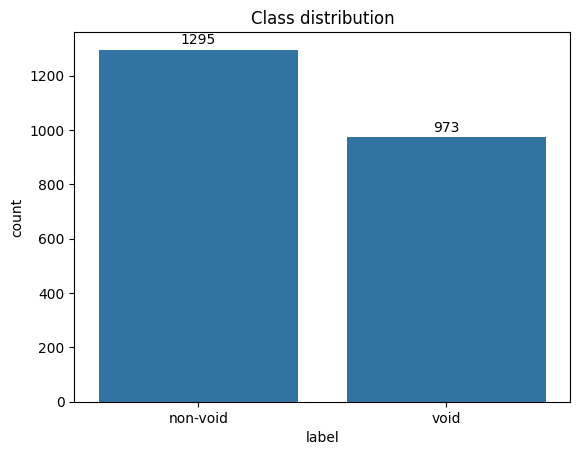

In [1518]:
plt.figure()
ax = sns.countplot(x='label',
                   data=features,
                   order=features.label.value_counts().index)

# Manually add value labels
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{int(height)}',
            ha='center', va='bottom')

plt.title('Class distribution')
plt.show()

In [1519]:
X = features.drop(columns=['label', 'experiment_id'])
y = features['label']
groups = features['experiment_id']

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

Scale and fit on training data only

In [1520]:
scaler = StandardScaler()
pca = PCA()

In [1521]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
pca.fit(X_train_scaled)

PCA()

Transform both train and test using the same fitted PCA

In [1522]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1


In [1523]:
pca_final = PCA(n_components=3)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)



In [1524]:
def setup_xgboost_with_imbalance_handling(X_train, y_train, use_smote=False, original_scale_weight=1.27):
    """
    Set up XGBoost with appropriate imbalance handling
    """
    if use_smote:
        print("Applying SMOTE...")
        smote = SMOTE(random_state=42)
        X_balanced, y_balanced = smote.fit_resample(X_train, y_train)
        
        # Check if we still need scale_pos_weight
        unique, counts = np.unique(y_balanced, return_counts=True)
        ratio = counts[0] / counts[1]
        
        if abs(ratio - 1.0) > 0.1:
            scale_weight = ratio
            print(f"Post-SMOTE imbalance detected, using scale_pos_weight: {scale_weight:.3f}")
        else:
            scale_weight = None
            print("Classes balanced after SMOTE, not using scale_pos_weight")
    else:
        print("No SMOTE applied, using original scale_pos_weight")
        X_balanced, y_balanced = X_train, y_train
        scale_weight = original_scale_weight
    
    # Configure XGBoost
    xgb_params = {        
        'n_estimators':200,
        'max_depth':5,
        'learning_rate':0.1,
        'subsample':0.8,
        'colsample_bytree':0.8,
        'random_state':42,
        'eval_metric':'logloss',
        'reg_alpha':0.1,   # L1 regularization
        'reg_lambda':1.0,  # L2 regularization
        'verbosity':0
    }
    
    if scale_weight is not None:
        xgb_params['scale_pos_weight'] = scale_weight
        
        

    
    model = XGBClassifier(**xgb_params)
    
    return model, X_balanced, y_balanced, xgb_params

In [1525]:
model, X_train_final, y_train_final, params = setup_xgboost_with_imbalance_handling(
                                        X_train_pca, 
                                        y_train,
                                        use_smote=False,  # Switch this as needed
                                        original_scale_weight=1.27
                                    )

No SMOTE applied, using original scale_pos_weight


In [1526]:
label_encoder = LabelEncoder()
# Encode y_test and y_train
y_train_encoded = label_encoder.fit_transform(y_train_final) 
y_test_encoded = label_encoder.transform(y_test)

In [1527]:
eval_set = [(X_train_final, y_train_encoded), (X_test_pca, y_test_encoded)]
model.fit(X_train_final, y_train_encoded, eval_set=eval_set, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [1528]:
# Classification report
preds = model.predict(X_test_pca)
y_pred = label_encoder.inverse_transform(preds)
y_pred_prob = model.predict_proba(X_test_pca)
y_pred_labels = label_encoder.inverse_transform(np.argmax(y_pred_prob, axis=1))
report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

    non-void       0.72      0.82      0.76       364
        void       0.66      0.52      0.58       246

    accuracy                           0.70       610
   macro avg       0.69      0.67      0.67       610
weighted avg       0.69      0.70      0.69       610



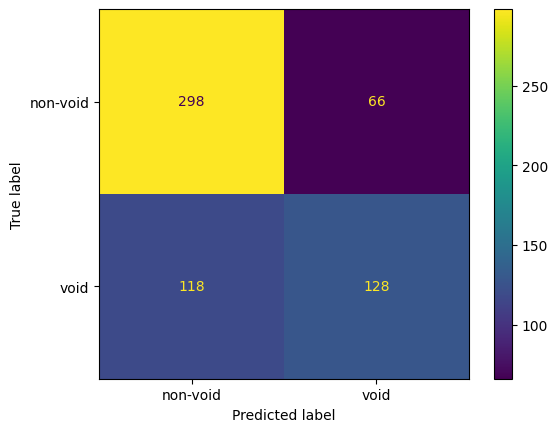

In [1529]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['non-void', 'void'])
cm_display.plot()
# plt.title('5s sliding window, 0.8 overlap, smote')
cm_fig_path = 'model_plots/two_class_results/cm_5s_0.8_smote.png'
# plt.savefig(cm_fig_path)
plt.show()


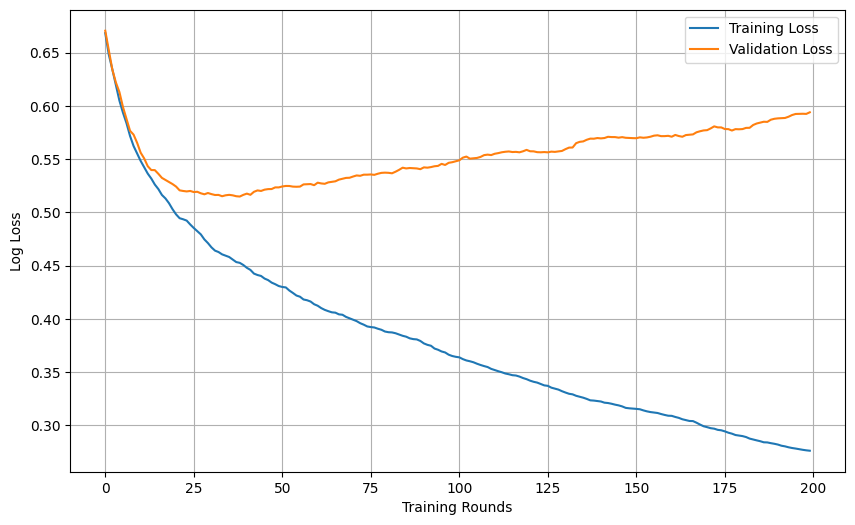

In [1530]:
# Retrieve the evaluation results
results = model.evals_result()
train_loss = results['validation_0']['logloss']
test_loss = results['validation_1']['logloss']

# Plot the loss function
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(test_loss, label='Validation Loss')
plt.xlabel('Training Rounds')
plt.ylabel('Log Loss')
# plt.title('5s sliding window, 0.8 overlap, smote')
plt.legend()
plt.grid(True)
loss_fig_path = 'model_plots/two_class_results/loss_5s_0.8_smote.png'
# plt.savefig(loss_fig_path)
plt.show()

In [1531]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_dict

{'non-void': {'precision': 0.7163461538461539,
  'recall': 0.8186813186813187,
  'f1-score': 0.764102564102564,
  'support': 364.0},
 'void': {'precision': 0.6597938144329897,
  'recall': 0.5203252032520326,
  'f1-score': 0.5818181818181818,
  'support': 246.0},
 'accuracy': 0.6983606557377049,
 'macro avg': {'precision': 0.6880699841395718,
  'recall': 0.6695032609666756,
  'f1-score': 0.6729603729603729,
  'support': 610.0},
 'weighted avg': {'precision': 0.6935398005746155,
  'recall': 0.6983606557377049,
  'f1-score': 0.6905911574764033,
  'support': 610.0}}

## Upload to MLFlow

In [1532]:
import mlflow
from mlflow.models.signature import infer_signature

In [1533]:
import mlflow
import mlflow.xgboost
from mlflow.models.signature import infer_signature
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import os

def log_experiment_run(
    model,
    X_test,
    report_dict,
    loss_fig_path,
    cm_fig_path,
    data_path,
    params,
    experiment_name="Posture Detection - Window Size Tuning",
    model_name="XGBoost"
):

    # Set experiment
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment(experiment_name)

    run_name = f"{params.get('window_size', 'NA')}s_win_{int(params.get('overlap', 0.0) * 100)}%_overlap"
    # run_name = f"{params.get('window_size', 'NA')}s_win_{int(params.get('overlap', 0.0) * 100)}%_overlap_{params.get('smote')}" # with smote
    
    del params['window_size']
    del params['overlap']

    with mlflow.start_run(run_name=run_name):
        # Log parameters
        mlflow.log_params(params)

        
        mlflow.log_metrics({
            "accuracy": report_dict.get("accuracy", 0.0),
            "recall_non_void": report_dict.get("non-void", {}).get("recall", 0.0),
            "recall_void": report_dict.get("void", {}).get("recall", 0.0),
            "f1_score_macro": report_dict.get("macro avg", {}).get("f1-score", 0.0)
        })

        # Log model with signature
        # input_example = X_test.iloc[:1]
        input_example = X_test[:1]
        signature = infer_signature(X_test, model.predict(X_test))

        try:
            mlflow.xgboost.log_model(
                xgb_model=model,
                artifact_path=model_name,
                input_example=input_example,
                signature=signature
            )
        except Exception as e:
            print("Error logging model:", e)
        
        # try:
        #     mlflow.log_artifact(cm_fig_path)
        # except Exception as e:
        #     print("Error logging artifact:", e)
            
        # try:
        #     mlflow.log_artifact(loss_fig_path)
        # except Exception as e:
        #     print("Error logging artifact:", e)
        
        # try:    
        #     mlflow.log_artifact(data_path)
        # except Exception as e:
        #     print("Error logging artifact:", e)


In [1534]:
from sklearn.metrics import classification_report

# # Example parameters
# params['window_size'] = 5
# params['overlap'] = 0.8
# params['smote'] = 'smote'
# params['exp_name'] = '5s_0.8_overlap'


# # y_pred = model.predict(X_test)
# report_dict = classification_report(y_test, y_pred, output_dict=True)

# log_experiment_run(model, X_test_pca, report_dict, cm_fig_path, data_path, loss_fig_path, params)

In [1535]:
# y_pred

## Prepare data for state space classification

In [1536]:
data_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/features_data_main/three_class_raw_2s_yo_0.8.csv'
three_class_features = pd.read_csv(data_path)
three_class_features.drop(['center_time', 'start_time', 'end_time'], axis= 1, inplace=True)

Get labels of three class data

In [1537]:
y_three_class = three_class_features['label']
y_3 = y_three_class.iloc[test_idx]


Probability output of XGBoost predictions 

In [1538]:
y_pred_prob = model.predict_proba(X_test_pca)[:, 1]


Experiment ids of test set

In [1539]:
exp_id = features['experiment_id'].iloc[test_idx]
test_experiment_ids = exp_id.unique()

In [1540]:
# y_pred

In [1541]:
# y_test_encoded

In [1542]:
df = pd.DataFrame({
    'exp_id': exp_id,
    'three_class_label': y_3,
    'two_class_label': y_test,
    'two_class_pred': y_pred,
    'two_class_pred_num': preds,
    'two_class_pred_prob': y_pred_prob
})

df.head()

,exp_id,three_class_label,two_class_label,two_class_pred,two_class_pred_num,two_class_pred_prob
191,5,post-void,non-void,non-void,0,0.048140
192,5,post-void,non-void,void,1,0.561188
193,5,post-void,non-void,non-void,0,0.177524
194,5,post-void,void,non-void,0,0.296419
195,5,post-void,void,non-void,0,0.428323


In [1543]:
df.to_csv('output/outputs.csv', index=False)

## State space classification

In [1544]:
def state_space_classifier(arr, window=7):  
    state_preds = []  
    state = 'pre-void'
    terminated = False
    arr_length = len(arr)
    
    i = 0
    while i < arr_length:
        if terminated:
            state_preds.append('post-void')
            i += 1
            continue
        
        if state == 'pre-void':
            if i + window <= arr_length and all(x == 1 for x in arr[i:i+window]):
                state = 'void'
                state_preds.append(state)
                i += 1
                continue
                
        elif state == 'void':
            if i + window <= arr_length and all(x == 0 for x in arr[i:i+window]):
                state = 'post-void'
                terminated = True
                state_preds.append(state)
                i += 1
                continue
        
        state_preds.append(state)
        i += 1
    
    return state_preds

In [1545]:
def state_space_classifier_prob(prob_arr, 
                        void_entry_threshold=0.5, 
                        void_exit_threshold=0.1,
                        entry_window=5,
                        exit_window=7,
                        min_consecutive_ratio=0.8):
    """
    State-based classifier using XGBoost probability outputs
    
    Parameters:
    - prob_arr: Array of P(void) probabilities from XGBoost
    - void_entry_threshold: Probability threshold to enter void state
    - void_exit_threshold: Probability threshold to exit void state  
    - entry_window: Window size for entering void state
    - exit_window: Window size for exiting void state
    - min_consecutive_ratio: Minimum ratio of window that must meet threshold
    """
    
    state_preds = []
    state = 'pre-void'
    terminated = False
    arr_length = len(prob_arr)
    
    i = 0
    while i < arr_length:
        if terminated:
            state_preds.append('post-void')
            i += 1
            continue
        
        if state == 'pre-void':
            # Check if we have enough values for entry window
            if i + entry_window <= arr_length:
                window_probs = prob_arr[i:i+entry_window]
                
                # Check if enough of the window meets void threshold
                above_threshold = np.sum(window_probs >= void_entry_threshold)
                if above_threshold >= (entry_window * min_consecutive_ratio):
                    # Additional check: window mean should be high
                    if np.mean(window_probs) >= void_entry_threshold:
                        state = 'void'
                        state_preds.append(state)
                        i += 1
                        continue
                        
        elif state == 'void':
            # Check if we have enough values for exit window
            if i + exit_window <= arr_length:
                window_probs = prob_arr[i:i+exit_window]
                
                # Check if enough of the window meets non-void threshold
                below_threshold = np.sum(window_probs <= void_exit_threshold)
                if below_threshold >= (exit_window * min_consecutive_ratio):
                    # Additional check: window mean should be low
                    if np.mean(window_probs) <= void_exit_threshold:
                        state = 'post-void'
                        terminated = True
                        state_preds.append(state)
                        i += 1
                        continue
        
        state_preds.append(state)
        i += 1
    
    return state_preds

In [1546]:
def adaptive_state_classifier(prob_arr, 
                            base_entry_threshold=0.5,
                            base_exit_threshold=0.1,
                            entry_window=5,
                            exit_window=7,
                            confidence_boost=0.1):
    """
    Adaptive version that adjusts thresholds based on recent probability trends
    """
    
    state_preds = []
    state = 'pre-void'
    terminated = False
    arr_length = len(prob_arr)
    
    i = 0
    while i < arr_length:
        if terminated:
            state_preds.append('post-void')
            i += 1
            continue
        
        # Calculate recent trend (last 3 values)
        recent_start = max(0, i-3)
        recent_probs = prob_arr[recent_start:i+1]
        trend = np.mean(np.diff(recent_probs)) if len(recent_probs) > 1 else 0
        
        if state == 'pre-void':
            # Lower threshold if trend is increasing (more confident about void)
            entry_threshold = base_entry_threshold - (confidence_boost if trend > 0 else 0)
            
            if i + entry_window <= arr_length:
                window_probs = prob_arr[i:i+entry_window]
                window_mean = np.mean(window_probs)
                window_std = np.std(window_probs)
                
                # Transition if mean is high and low variance (stable high confidence)
                if (window_mean >= entry_threshold and 
                    window_std < 0.2 and  # Low variance requirement
                    np.min(window_probs) >= entry_threshold - 0.1):  # No big dips
                    
                    state = 'void'
                    state_preds.append(state)
                    i += 1
                    continue
                    
        elif state == 'void':
            # Higher threshold if trend is decreasing (more confident about non-void)
            exit_threshold = base_exit_threshold + (confidence_boost if trend < 0 else 0)
            
            if i + exit_window <= arr_length:
                window_probs = prob_arr[i:i+exit_window]
                window_mean = np.mean(window_probs)
                window_std = np.std(window_probs)
                
                # Transition if mean is low and stable
                if (window_mean <= exit_threshold and 
                    window_std < 0.2 and  # Low variance requirement
                    np.max(window_probs) <= exit_threshold + 0.1):  # No big spikes
                    
                    state = 'post-void'
                    terminated = True
                    state_preds.append(state)
                    i += 1
                    continue
        
        state_preds.append(state)
        i += 1
    
    return state_preds

In [1547]:
def confidence_weighted_classifier(prob_arr, confidence_arr=None, 
                                 void_threshold=0.7, 
                                 non_void_threshold=0.3,
                                 min_confidence=0.6,
                                 window=5):
    """
    Version that incorporates prediction confidence
    confidence_arr: Array of confidence scores (e.g., max probability from predict_proba)
    """
    
    if confidence_arr is None:
        # Use probability distance from 0.5 as confidence proxy
        confidence_arr = np.abs(prob_arr - 0.5) * 2
    
    state_preds = []
    state = 'pre-void'
    terminated = False
    arr_length = len(prob_arr)
    
    i = 0
    while i < arr_length:
        if terminated:
            state_preds.append('post-void')
            i += 1
            continue
        
        if state == 'pre-void':
            if i + window <= arr_length:
                window_probs = prob_arr[i:i+window]
                window_conf = confidence_arr[i:i+window]
                
                # Only consider high-confidence predictions
                high_conf_mask = window_conf >= min_confidence
                if np.sum(high_conf_mask) >= window * 0.6:  # At least 60% high confidence
                    high_conf_probs = window_probs[high_conf_mask]
                    
                    if np.mean(high_conf_probs) >= void_threshold:
                        state = 'void'
                        state_preds.append(state)
                        i += 1
                        continue
                        
        elif state == 'void':
            if i + window <= arr_length:
                window_probs = prob_arr[i:i+window]
                window_conf = confidence_arr[i:i+window]
                
                # Only consider high-confidence predictions
                high_conf_mask = window_conf >= min_confidence
                if np.sum(high_conf_mask) >= window * 0.6:
                    high_conf_probs = window_probs[high_conf_mask]
                    
                    if np.mean(high_conf_probs) <= non_void_threshold:
                        state = 'post-void'
                        terminated = True
                        state_preds.append(state)
                        i += 1
                        continue
        
        state_preds.append(state)
        i += 1
    
    return state_preds

In [1548]:
import numpy as np
from hmmlearn import hmm

def hmm_classifier_with_outputs(acc):
    observations = np.array(acc).reshape(-1, 1)  # Use the predictions from the DataFrame

    # Step 2: Define HMM parameters
    # Hidden states: 0 = pre-void, 1 = void, 2 = post-void
    n_states = 3
    n_observations = 2  # 0 and 1 from XGBoost

    # Transition matrix: left-to-right (no jumping back)
    # Rows = from-state, Cols = to-state
    transmat = np.array([
        [0.8, 0.2, 0.0],  # pre-void
        [0.0, 0.8, 0.2],  # void
        [0.0, 0.0, 1.0]   # post-void (absorbing)
    ])

    # Emission probabilities
    # Each row corresponds to a hidden state:
    # [P(non-void|state), P(void|state)]
    emissionprob = np.array([
        [0.9, 0.1],  # pre-void mostly emits non-void
        [0.2, 0.8],  # void mostly emits void
        [0.8, 0.2]   # post-void mostly emits non-void again
    ])

    # Start probabilities
    startprob = np.array([1.0, 0.0, 0.0])  # always start in pre-void

    # Step 3: Create and apply the model
    model = hmm.CategoricalHMM(
        n_components=n_states,
        init_params="",
        n_iter=10
    )

    model.startprob_ = startprob
    model.transmat_ = transmat
    model.emissionprob_ = emissionprob

    # Step 4: Decode hidden states
    logprob, hidden_states = model.decode(observations, algorithm="viterbi")

    # Step 5: Map numeric states to labels
    state_map = {0: 'pre-void', 1: 'void', 2: 'post-void'}
    state_sequence = [state_map[s] for s in hidden_states]
    
    
    return state_sequence

In [1549]:
import numpy as np
from hmmlearn import hmm

def hmm_classifier_with_probs(probs):
    # Step 1: Define observed sequence from XGBoost model
    bins = np.digitize(probs, bins=[0.2, 0.5])
    observations = probs.reshape(-1, 1)  # Use the probabilities from the XGBoost model
    # Step 2: Define HMM parameters
    # Hidden states: 0 = pre-void, 1 = void, 2 = post-void
    n_states = 3
    n_observations = 2  # 0 and 1 from XGBoost

    # Transition matrix: left-to-right (no jumping back)
    # Rows = from-state, Cols = to-state
    transmat = np.array([
        [0.8, 0.2, 0.0],  # pre-void
        [0.0, 0.8, 0.2],  # void
        [0.0, 0.0, 1.0]   # post-void (absorbing)
    ])

    # Emission probabilities
    # Each row corresponds to a hidden state:
    # [P(non-void|state), P(void|state)]
    emissionprob = np.array([
        [0.9, 0.1, 0.0],  # pre-void emits mostly low probability
        [0.1, 0.2, 0.7],  # void emits high probability
        [0.8, 0.2, 0.0]   # post-void emits mostly low probability again
    ])

    # Start probabilities
    startprob = np.array([1.0, 0.0, 0.0])  # always start in pre-void

    # Step 3: Create and apply the model
    model = hmm.CategoricalHMM(
        n_components=n_states,
        init_params="",
        n_iter=10
    )

    model.startprob_ = startprob
    model.transmat_ = transmat
    model.emissionprob_ = emissionprob

    # Step 4: Decode hidden states
    logprob, hidden_states = model.decode(observations, algorithm="viterbi")

    # Step 5: Map numeric states to labels
    state_map = {0: 'pre-void', 1: 'void', 2: 'post-void'}
    state_sequence = [state_map[s] for s in hidden_states]
    
    
    return state_sequence

# Output
# print("Binary observations:", observations.ravel().tolist())
# print("Decoded HMM states:", state_sequence)

In [1550]:
def hmm_classifier_with_prob_bins(probs):
    # Step 1: Define observed sequence from XGBoost model
    bins = np.digitize(probs, bins=[0.2, 0.5])
    observations = bins.reshape(-1, 1)  # Use the probabilities from the XGBoost model
    
    # Step 2: Define HMM parameters
    # Hidden states: 0 = pre-void, 1 = void, 2 = post-void
    n_states = 3
    n_observations = 2  # 0 and 1 from XGBoost

    # Transition matrix: left-to-right (no jumping back)
    # Rows = from-state, Cols = to-state
    transmat = np.array([
        [0.8, 0.2, 0.0],  # pre-void
        [0.0, 0.8, 0.2],  # void
        [0.0, 0.0, 1.0]   # post-void (absorbing)
    ])

    # Emission probabilities
    # Each row corresponds to a hidden state:
    # [P(non-void|state), P(void|state)]

    emissionprob = np.array([
        [0.9, 0.1, 0.0],  # pre-void emits mostly low probability
        [0.1, 0.2, 0.7],  # void emits high probability
        [0.8, 0.2, 0.0]   # post-void emits mostly low probability again
    ])

    # Start probabilities
    startprob = np.array([1.0, 0.0, 0.0])  # always start in pre-void

    # Step 3: Create and apply the model
    model = hmm.CategoricalHMM(
        n_components=n_states,
        init_params="",
        n_iter=10
    )

    model.startprob_ = startprob
    model.transmat_ = transmat
    model.emissionprob_ = emissionprob

    # Step 4: Decode hidden states
    logprob, hidden_states = model.decode(observations, algorithm="viterbi")

    # Step 5: Map numeric states to labels
    state_map = {0: 'pre-void', 1: 'void', 2: 'post-void'}
    state_sequence = [state_map[s] for s in hidden_states]
    
    
    return state_sequence

In [1551]:
def hmm_classifier_with_probs_gaus(probs):

    obs = probs.reshape(-1, 1)

    # model_hmm = GaussianHMM(n_components=3, covariance_type="full", n_iter=10, init_params="")
    model_hmm = GaussianHMM(n_components=3, covariance_type="full")


    # Set initial parameters or let it learn from unsupervised training
    model_hmm.startprob_ = np.array([1.0, 0.0, 0.0])
    model_hmm.transmat_ = np.array([
        [0.9, 0.1, 0.0],
        [0.0, 0.8, 0.2],
        [0.0, 0.0, 1.0]
    ])

    # Fit to learn emission parameters, or set manually
    model_hmm.fit(obs)  # optional: or fit with constraints
    model_hmm.means_ = np.array([[0.2], [0.8], [0.2]])  # Expected P(void) for each state
    model_hmm.covars_ = np.array([[[0.1]], [[0.1]], [[0.1]]])  # Variance

    # logprob, hidden_states = model_hmm.decode(obs, algorithm="viterbi")
    hidden_states = model_hmm.predict(obs)
    
    state_map = {0: 'pre-void', 1: 'void', 2: 'post-void'}
    state_sequence = [state_map[s] for s in hidden_states]
    
    return state_sequence

In [1552]:
def hmm_state_classifier_c(void_probs, n_states=3):
    """
    Use HMM with XGBoost probabilities as observations
    States: 0=pre-void, 1=void, 2=post-void
    """
    
    # Reshape for hmmlearn (needs 2D array)
    observations = void_probs.reshape(-1, 1)
    
    # Create HMM model
    model = hmm.GaussianHMM(n_components=n_states, covariance_type="full")
    
    # Define state transition constraints
    # pre-void -> void -> post-void (mostly forward progression)
    transmat = np.array([
        [0.9, 0.1, 0.0],    # pre-void: mostly stay, can go to void
        [0.0, 0.8, 0.2],    # void: mostly stay, can go to post-void
        [0.0, 0.0, 1.0]     # post-void: terminal state
    ])
    
    model.transmat_ = transmat
    
    # Set initial state probabilities (always start in pre-void)
    model.startprob_ = np.array([1.0, 0.0, 0.0])
    
    # Set emission parameters based on expected probabilities
    # Pre-void: low void probability
    # Void: high void probability  
    # Post-void: low void probability
    model.means_ = np.array([[0.2], [0.5], [0.1]])  # Expected P(void) for each state
    model.covars_ = np.array([[[0.1]], [[0.1]], [[0.1]]])  # Variance
    
    # Predict most likely state sequence
    hidden_states = model.predict(observations)
    
    state_map = {0: 'pre-void', 1: 'void', 2: 'post-void'}
    state_sequence = [state_map[s] for s in hidden_states]
    
    return state_sequence

In [1553]:
def custom_hmm_classifier(void_probs, n_bins=5):
    """
    Discretize probabilities and use custom HMM
    """
    
    # Bin probabilities into discrete observations
    bins = np.linspace(0, 1, n_bins + 1)
    observations = np.digitize(void_probs, bins) - 1
    
    transmat = np.array([
        [0.9, 0.1, 0.0],    # pre-void: mostly stay, can go to void
        [0.0, 0.8, 0.2],    # void: mostly stay, can go to post-void
        [0.0, 0.0, 1.0]     # post-void: terminal state
    ])
    
    # Define emission probabilities
    # P(observation | state) for each state
    emission_probs = np.array([
        [0.4, 0.3, 0.2, 0.1, 0.0],  # pre-void: favor low void probs
        [0.0, 0.1, 0.2, 0.3, 0.4],  # void: favor high void probs
        [0.4, 0.3, 0.2, 0.1, 0.0]   # post-void: favor low void probs
    ])
    
    
    # Use Viterbi algorithm to find most likely state sequence
    hidden_states = viterbi_decode(observations, transmat, emission_probs)
    
    
    state_map = {0: 'pre-void', 1: 'void', 2: 'post-void'}
    state_sequence = [state_map[s] for s in hidden_states]
    
    return state_sequence

In [1554]:
# probs = y_pred_prob[:,1]  # Probability of being in the 'void' class

In [1555]:
# bins = np.digitize(probs, bins=[0.2, 0.5])  # results in 0, 1, 2


In [1556]:
preds = model.predict(X_test_pca)

In [1557]:
all_preds = []
for exp_id in test_experiment_ids:
    exp_df = df[df['exp_id'] == exp_id]
    # print(exp_df.head(20))
    # exp = exp_df['two_class_pred_num'].values # using raw predictions
    exp = exp_df['two_class_pred_prob'].values  # using probabilities
    # exp_enc = label_encoder.transform(exp)
    # exp_mask = (test_groups == exp_id)
    # exp_preds = test_preds[exp_mask]
    # exp_state_preds = state_space_classifier(exp, window=7)
    exp_state_preds = state_space_classifier_prob(exp)
    # exp_state_preds = adaptive_state_classifier(exp)
    # exp_state_preds = confidence_weighted_classifier(exp)
    # exp_state_preds = hmm_classifier_with_outputs(exp)
    # exp_state_preds = hmm_classifier_with_probs(exp)
    # exp_state_preds = hmm_classifier_with_prob_bins(exp)
    # exp_state_preds = hmm_classifier_with_probs_gaus(exp)
    # exp_state_preds = hmm_state_classifier_c(exp)
    # exp_state_preds = custom_hmm_classifier(exp)
    # print(exp_state_preds)
    all_preds.extend(exp_state_preds)
    # Evaluate this experiment

In [1558]:
target_order = ['pre-void', 'void', 'post-void']
report = classification_report(y_3, all_preds, labels=target_order)

print(report)

              precision    recall  f1-score   support

    pre-void       0.12      0.22      0.16        89
        void       0.42      0.40      0.41       305
   post-void       0.15      0.11      0.13       216

    accuracy                           0.27       610
   macro avg       0.23      0.25      0.23       610
weighted avg       0.28      0.27      0.28       610



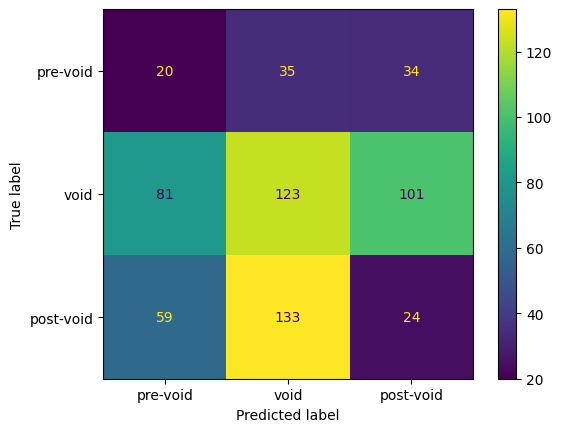

In [1559]:
labels = ['pre-void', 'void', 'post-void']

cm = confusion_matrix(y_3, all_preds, labels=labels)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = labels)
cm_display.plot()
# plt.title('5s sliding window, 0.8 overlap, smote')
# cm_fig_path = 'model_plots/two_class_results/cm_5s_0.8_smote.png'
# plt.savefig(cm_fig_path)
plt.show()

In [1560]:
print("Accuracy: ", accuracy_score(y_3, all_preds))

Accuracy:  0.27377049180327867


In [1561]:
df['three_class_pred'] = all_preds
df.head()

,exp_id,three_class_label,two_class_label,two_class_pred,two_class_pred_num,two_class_pred_prob,three_class_pred
191,5,post-void,non-void,non-void,0,0.048140,pre-void
192,5,post-void,non-void,void,1,0.561188,pre-void
193,5,post-void,non-void,non-void,0,0.177524,pre-void
194,5,post-void,void,non-void,0,0.296419,pre-void
195,5,post-void,void,non-void,0,0.428323,pre-void


In [1562]:
df.to_csv('output/outputs.csv', index=False)

# Validation

In [1563]:
data_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/features_data_main/two_class_val.csv'
features = pd.read_csv(data_path)
features.drop(['center_time', 'start_time', 'end_time'], axis= 1, inplace=True)
features

,acc_x_permutation_entropy,acc_x_spectral_entropy,acc_x_mean,acc_x_std,acc_x_range,acc_x_rms,acc_x_var,acc_x_min,acc_x_max,acc_x_time_energy,...,gyr_mag_std,gyr_mag_range,gyr_mag_rms,gyr_mag_var,gyr_mag_min,gyr_mag_max,gyr_mag_time_energy,gyr_mag_spectral_energy,label,experiment_id
0,0.799202,0.591856,1.542636,0.869334,3.882699,1.770725,0.755741,-0.429822,3.452877,438.965360,...,1.217277,4.493880,2.825545,1.481762,0.774982,5.268863,1117.718967,156480.655315,void,1
1,0.805814,0.626047,1.309300,0.886999,4.056334,1.581466,0.786768,-0.603457,3.452877,350.144851,...,1.227359,4.806653,3.151122,1.506410,0.462209,5.268863,1390.139876,194619.582690,void,1
2,0.809422,0.641016,1.194436,0.864417,4.056334,1.474413,0.747217,-0.603457,3.452877,304.345269,...,1.161746,4.859776,3.363546,1.349654,0.462209,5.321985,1583.882038,221743.485253,void,1
3,0.823303,0.660757,0.906825,0.830852,4.056334,1.229897,0.690315,-0.603457,3.452877,211.770542,...,1.183510,4.859776,3.354463,1.400697,0.462209,5.321985,1575.339099,220547.473855,void,1
4,0.814705,0.658221,0.782069,0.753857,2.959957,1.086247,0.568300,-0.603457,2.356499,165.190478,...,1.238114,4.859776,3.266058,1.532925,0.462209,5.321985,1493.398718,209075.820567,void,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,0.930832,0.730233,-1.178798,0.731628,3.633834,1.387388,0.535279,-3.617976,0.015858,269.478188,...,1.235417,5.315622,2.251936,1.526256,0.312845,5.628466,709.970431,99395.860359,void,2
101,0.932324,0.733342,-1.144809,0.760778,3.798803,1.374544,0.578783,-3.617976,0.180827,264.511894,...,1.139086,5.315622,2.384957,1.297517,0.312845,5.628466,796.322961,111485.214506,void,2
102,0.931391,0.731257,-1.048505,0.811455,3.798803,1.325829,0.658460,-3.617976,0.180827,246.095186,...,1.113900,5.315622,2.471362,1.240772,0.312845,5.628466,855.068405,119709.576741,void,2
103,0.925552,0.702774,-1.158220,0.780274,3.798803,1.396532,0.608827,-3.617976,0.180827,273.042075,...,1.049136,5.075138,2.483381,1.100686,0.553328,5.628466,863.405358,120876.750124,void,2


In [1564]:
X_val = features.drop(columns=['label', 'experiment_id'])
y_val = features['label']

In [1565]:
X_val_scaled = scaler.transform(X_val)

In [1566]:
X_val_pca = pca_final.transform(X_val_scaled)

In [1567]:
preds = model.predict(X_val_pca)
y_pred = label_encoder.inverse_transform(preds)
report = classification_report(y_val, y_pred)

print(report)

              precision    recall  f1-score   support

    non-void       0.01      1.00      0.03         1
        void       1.00      0.28      0.44       104

    accuracy                           0.29       105
   macro avg       0.51      0.64      0.23       105
weighted avg       0.99      0.29      0.43       105



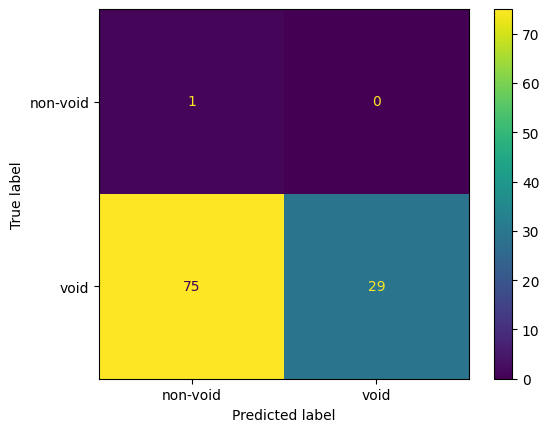

In [1568]:
# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['non-void', 'void'])
cm_display.plot()
plt.show()

In [1569]:
exp_id = features['experiment_id']
test_experiment_ids = features['experiment_id'].unique()

In [1570]:
y_pred_prob = model.predict_proba(X_val_pca)[:, 1]

In [1571]:
df_val = pd.DataFrame({
    'exp_id': exp_id,
    # 'three_class_label': y_3,
    'two_class_label': y_val,
    'two_class_pred': y_pred,
    # 'two_class_pred_num': preds,
    'two_class_pred_prob': y_pred_prob
})

In [1572]:
all_preds = []
for exp_id in test_experiment_ids:
    exp_df = df_val[df_val['exp_id'] == exp_id]
    exp = exp_df['two_class_pred_prob'].values  # using probabilities
    # exp_state_preds = state_space_classifier_prob(exp)
    exp_state_preds = hmm_state_classifier_c(exp)
    all_preds.extend(exp_state_preds)
    # Evaluate this experiment

In [1573]:
target_order = ['pre-void', 'void', 'post-void']
report = classification_report(y_val, all_preds, labels=target_order)

print(report)

              precision    recall  f1-score   support

    pre-void       0.00      0.00      0.00         0
        void       1.00      0.49      0.66       104
   post-void       0.00      0.00      0.00         0

   micro avg       0.49      0.49      0.49       104
   macro avg       0.33      0.16      0.22       104
weighted avg       1.00      0.49      0.66       104



/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter t

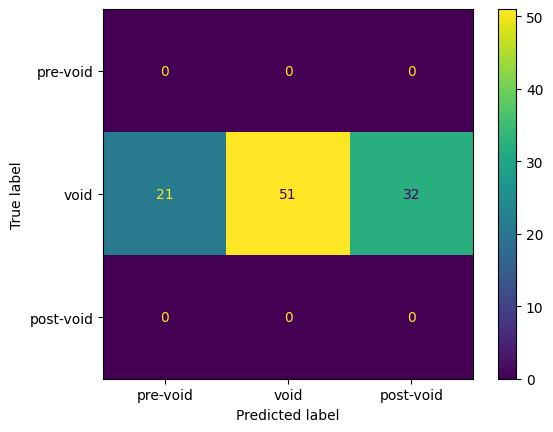

In [1574]:
labels = ['pre-void', 'void', 'post-void']

cm = confusion_matrix(y_val, all_preds, labels=labels)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = labels)
cm_display.plot()
# plt.title('5s sliding window, 0.8 overlap, smote')
# cm_fig_path = 'model_plots/two_class_results/cm_5s_0.8_smote.png'
# plt.savefig(cm_fig_path)
plt.show()

In [1575]:
# labels = ['pre-void', 'void', 'post-void']

# cm = confusion_matrix(y_3, all_preds, labels=labels)
# cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = labels)
# cm_display.plot()
# # plt.title('5s sliding window, 0.8 overlap, smote')
# # cm_fig_path = 'model_plots/two_class_results/cm_5s_0.8_smote.png'
# # plt.savefig(cm_fig_path)
# plt.show()

In [1576]:
# # y_pred_prob
# y_pre_prob_arr = np.array(y_pred_prob, dtype=float)
# np.set_printoptions(suppress=True, threshold=np.inf, linewidth=np.inf, precision=8)

# # Now print the array
# print(y_pre_prob_arr)

In [1577]:
# probs = y_pred_prob[:,1]  # Probability of being in the 'void' class
# probs


In [1578]:
# # Train the model
# # model = xgb.XGBClassifier()
# model.fit(X_train_final, y_train_encoded)

# # Predict on train and test
# train_preds = model.predict(X_train_final)
# test_preds = model.predict(X_test_pca)

# # Combine back into full prediction array in correct index positions
# full_preds = np.zeros(len(X), dtype=int)
# full_preds[train_idx] = train_preds
# full_preds[test_idx] = test_preds

In [1579]:
# test_preds

In [1580]:
# labels = label_encoder.fit_transform(y)

In [1581]:
# df = pd.DataFrame({
#     'experiment_id': features['experiment_id'],
#     'label': labels,
#     'prediction': full_preds,
# })

In [1582]:
# df.to_csv('label_prediction_num.csv', index=False)
# df.head()

Decoded labels

In [1583]:
# df = pd.DataFrame({
#     'experiment_id': features['experiment_id'],
#     'label': y,
#     'prediction': label_encoder.inverse_transform(full_preds),
# })

In [1584]:
# df.to_csv('label_prediction_str.csv', index=False)
# df.head()

In [1585]:
# label_df = pd.DataFrame({
#     'experiment_id': features['experiment_id'],
#     'label': features['label'],})

In [1586]:
# label_df.to_csv('original_labels.csv', index=False)
# label_df.head()